# Classification de commentaires citoyens sur les services publics (NLP)

**Test technique TAISS 2026 — sélection pour le stage Afriklang (Togo Data Lab)**
Auteur : Housseïne Tchatakoura — Python uniquement, graine aléatoire fixée (`SEED = 42`).

**Objectif.** Classer 150 commentaires citoyens en trois catégories : *Satisfaction*, *Insatisfaction*, *Suggestion*.

**Plan du notebook**

| Partie | Contenu |
|---|---|
| **1. Exploration & prétraitement** | 1.1 Chargement et exploration · 1.2 Nettoyage (stopwords, éwé/mina) · 1.3 Visualisations |
| **2. Modélisation** | 2.1 Vectorisation et split · 2.2 Entraînement de 4 algorithmes · 2.3 Évaluation, optimisation, analyse des erreurs |
| **3. Restitution** | Bonus (modèle sauvegardé, interface Streamlit, commentaires mixtes) · Conclusion, limites et pistes |

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_validate, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

SEED = 42                       # graine unique : split, validation croisée, modèles, nuages de mots
np.random.seed(SEED)
CLASSES = ["Satisfaction", "Insatisfaction", "Suggestion"]
PALETTE = {"Satisfaction": "#2e8b57", "Insatisfaction": "#c0392b", "Suggestion": "#2c6fbb"}
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

# Partie 1 — Exploration & prétraitement

## 1.1 Chargement et exploration

In [2]:
DATA_PATH = Path("data/dataset_nlp_test_tal.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {int(df.isna().sum().sum())} | textes dupliqués : {int(df['texte'].duplicated().sum())} | "
      f"identifiants uniques : {df['id'].is_unique}")
display(df.dtypes.to_frame("type"))
display(df.head())

Dimensions : 150 lignes x 3 colonnes
Valeurs manquantes : 0 | textes dupliqués : 0 | identifiants uniques : True


,type
id,int64
texte,str
categorie,str


,id,texte,categorie
0,1,Manque total de communication entre les services.,Insatisfaction
1,2,Il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion
2,3,Envoyer des SMS de confirmation lors de chaque étape du traitement.,Suggestion
3,4,Prévoir des interprètes pour les citoyens ne parlant pas le français.,Suggestion
4,5,Le formulaire en ligne plante au moment de la soumission.,Insatisfaction


In [3]:
# Quelques exemples par catégorie (tirage reproductible)
for category in CLASSES:
    print(f"\n--- {category} ---")
    for text in df.loc[df["categorie"] == category, "texte"].sample(4, random_state=SEED):
        print(" •", text)


--- Satisfaction ---
 • Tout s'est bien passé, merci pour votre professionnalisme.
 • Le bureau est bien situé et facilement accessible.
 • Processus transparent, j'ai pu suivre l'avancement de mon dossier.
 • J'ai reçu mon document dans les délais, service impeccable.

--- Insatisfaction ---
 • Les informations données par téléphone étaient erronées.
 • On m'a demandé des pièces non mentionnées sur le site officiel.
 • Service fermé sans préavis le jour de mon rendez-vous confirmé.
 • Le guichet était fermé sans aucune explication ni affichage.

--- Suggestion ---
 • Mettre en réseau les différentes mairies pour un meilleur partage des données.
 • Prévoir une ligne téléphonique distincte pour les urgences administratives.
 • Mettre à jour régulièrement le site web avec les nouvelles procédures.
 • Afficher clairement les délais de traitement à l'entrée des services.


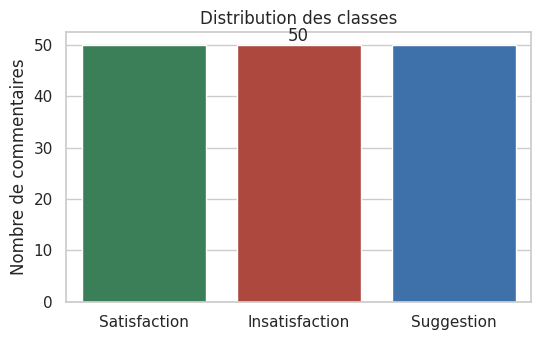

n_caracteres      n_mots     
                       mean  std   mean  std
categorie                                   
Satisfaction           57.4  8.3    8.7  1.6
Insatisfaction         57.8  8.0    9.3  1.6
Suggestion             69.8  5.3   10.5  1.4

In [4]:
# Distribution des classes + longueur moyenne des textes par catégorie
df["n_caracteres"] = df["texte"].str.len()
df["n_mots"] = df["texte"].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(data=df, x="categorie", order=CLASSES, palette=PALETTE, hue="categorie", legend=False, ax=ax)
ax.bar_label(ax.containers[0]); ax.set_title("Distribution des classes"); ax.set_xlabel(""); ax.set_ylabel("Nombre de commentaires")
plt.show()

length_by_class = df.groupby("categorie")[["n_caracteres", "n_mots"]].agg(["mean", "std"]).loc[CLASSES].round(1)
display(length_by_class)

**Observations.**
- Le jeu de données compte **150 commentaires** (3 colonnes : `id` entier, `texte` et `categorie` en texte), sans valeur manquante ni doublon.
- Les classes sont **parfaitement équilibrées (50 / 50 / 50)** : aucun rééquilibrage n'est nécessaire et l'accuracy reste interprétable (on suivra aussi le F1 macro).
- **Les Suggestions sont plus longues** : 69,8 caractères (10,5 mots) en moyenne, contre ≈ 57,5 caractères (8,7 à 9,3 mots) pour la Satisfaction et l'Insatisfaction, avec une dispersion plus faible (σ = 5,3 contre ≈ 8). La longueur ne sépare donc que les Suggestions des deux autres classes : Satisfaction et Insatisfaction ont des longueurs quasi identiques.
- Les textes sont très courts (≈ 9 mots) : peu de contexte par exemple, ce qui limite ce que peut apprendre un modèle.

## 1.2 Nettoyage du texte

Toute la logique de prétraitement vit dans un module `nlp_utils.py`, **écrit par la cellule ci-dessous** (`%%writefile`) : le code reste visible dans le notebook, et la même fonction est réutilisée à l'identique par l'interface Streamlit (pas de duplication, pas de divergence entre entraînement et production).

**Étapes** : minuscules → suppression des accents (sauf lettres éwé `ɛ ɔ ɖ ŋ ƒ ɣ ʋ`) → élisions développées (`j'ai` → `je ai`, `n'ai` → `ne ai`) → suppression de la ponctuation, des chiffres et des caractères spéciaux → stratégie éwé/mina → tokenisation → stopwords.

**Pourquoi neutraliser les accents ?** Les graphies varient selon le clavier (`Yèvu`/`Yevu`, `délai`/`delai`) : on réduit le vocabulaire sans perdre d'information utile sur un corpus de cette taille.

**Stopwords : une liste maison, pas une liste standard.** Une liste générique supprime des mots qui portent justement le signal de classe. J'ai donc retiré des stopwords :
- **les négations** (`ne, pas, aucun(e), jamais, rien, sans, personne, non`) : *« Aucune réponse »*, *« sans solution »* sont la marque des plaintes ;
- **les marqueurs d'intensité** (`très, trop, plus, moins, bien`) : *« très satisfait »*, *« trop long »* ;
- **les pronoms de première personne** (`je, me, mon, ma, mes, on, nous, vous`) : ils signalent un récit d'expérience vécue (Satisfaction/Insatisfaction), alors que les Suggestions sont impersonnelles (constat chiffré en 1.3) ;
- **les marqueurs de modalité** (`serait, faudrait, faut, pour, il`) : *« Il serait utile de… »*, *« …pour réduire… »* caractérisent les Suggestions.

Ne sont supprimés que les mots purement grammaticaux : articles, déterminants possessifs de 2ᵉ/3ᵉ personne, prépositions et conjonctions de liaison, formes conjuguées de *être/avoir*, quelques adverbes vides. L'assertion `assert not (STOPWORDS_FR & GARDES_CRITIQUES)` garantit qu'aucun mot protégé ne se glisse dans la liste.

**Stratégie éwé/mina.** Seuls 3 commentaires sur 150 (2 %) contiennent de l'éwé : on ne peut donc pas *apprendre* de sens à partir de si peu d'exemples. Stratégie retenue : **conserver** les tokens éwé comme des mots à part entière (ils restent utilisables par le modèle, et les lettres éwé ne sont pas détruites par le nettoyage), et fournir un **mini-glossaire** de traductions sûres (`akpe` → *merci*, `nyuie` → *bien*) activable via `ewe_strategy="translate"`. Les trois options (`keep`, `translate`, `remove`) sont comparées en validation croisée dans la section 2.3.

In [5]:
%%writefile nlp_utils.py
"""Prétraitement et indices stylistiques pour les commentaires citoyens (français + insertions éwé/mina)."""
import re
import unicodedata

import numpy as np

# =============================================================================
# 1. Stratégie éwé/mina
# =============================================================================
# Lettres propres à l'éwé : elles ne se décomposent pas en NFKD, donc elles sont conservées telles quelles.
EWE_LETTERS = "ɛɔɖŋƒɣʋ"
# Marqueurs éwé repérés dans le corpus (comparés après normalisation, donc sans accents).
EWE_MARKERS = {"mele", "via", "megbe", "yevu", "nyuie", "hafi", "akpe", "wo"}
# Mini-glossaire : uniquement les traductions certaines (expressions d'abord, puis mots isolés).
EWE_PHRASES = {"akpe na wo": "merci"}
EWE_WORDS = {"akpe": "merci", "nyuie": "bien"}

# =============================================================================
# 2. Stopwords français (liste maison, justifiée dans le notebook)
# =============================================================================
STOPWORDS_FR = {
    # articles et déterminants
    "le", "la", "les", "un", "une", "des", "du", "de", "d", "au", "aux", "ce", "cet", "cette", "ces",
    "ton", "ta", "tes", "son", "sa", "ses", "notre", "nos", "votre", "vos", "leur", "leurs",
    # pronoms sans valeur discriminante, relatifs, démonstratifs
    "tu", "elle", "ils", "elles", "te", "se", "lui", "qui", "que", "dont", "ou",
    "celui", "celle", "ceux", "cela", "ca", "ceci",
    # prépositions et conjonctions de liaison
    "a", "dans", "par", "sur", "sous", "avec", "chez", "entre", "vers", "depuis", "pendant", "avant", "apres",
    "et", "ni", "mais", "donc", "or", "car", "si", "comme", "lors", "afin",
    # formes conjuguées d'être/avoir (le conditionnel « serait » est volontairement conservé)
    "est", "es", "suis", "sommes", "etes", "sont", "etais", "etait", "etaient", "ete", "etre",
    "ai", "as", "avons", "avez", "ont", "avait", "avaient", "avoir", "eu",
    # quelques adverbes sans valeur discriminante
    "alors", "aussi", "ainsi", "encore", "deja", "meme", "autre", "autres", "quelque", "quelques",
}
# Mots volontairement CONSERVÉS, bien que présents dans la plupart des listes standard :
#  - négations : ne, pas, non, aucun(e), jamais, rien, sans, personne -> polarité (Insatisfaction)
#  - intensité : tres, trop, plus, moins, bien, tout, tous
#  - première personne et « il » impersonnel : je, me, mon, ma, mes, on, nous, vous, il, en, y
#    -> récits d'expérience vécue (Satisfaction/Insatisfaction) vs formulations impersonnelles (Suggestion)
#  - modalité/conditionnel : serait, faudrait, faut, pour -> marqueurs de Suggestion
GARDES_CRITIQUES = {
    "ne", "pas", "non", "aucun", "aucune", "jamais", "rien", "sans", "personne",
    "tres", "trop", "plus", "moins", "bien", "tout", "tous",
    "je", "me", "mon", "ma", "mes", "on", "nous", "vous", "il", "en", "y",
    "pour", "serait", "faut", "faudrait",
}
assert not (STOPWORDS_FR & GARDES_CRITIQUES), "Un mot critique ne doit pas figurer dans les stopwords"

# Liste d'affichage (nuages de mots, top 15) : on masque EN PLUS les mots-outils conservés pour le modèle
# (pronoms, « ne », « pour »…) et le terme omniprésent « service », afin que les graphiques montrent les mots de contenu.
STOPWORDS_VISU = STOPWORDS_FR | {"je", "me", "mon", "ma", "mes", "on", "nous", "vous", "il", "en", "y", "ne", "pour",
                                 "tout", "tous", "plus", "moins", "service", "services"}

# Élisions restituées sous leur forme pleine : on préserve « je », « me » et surtout la négation « ne ».
ELISIONS = {"j": "je", "m": "me", "t": "te", "s": "se", "n": "ne", "l": "le", "c": "ce", "d": "de"}


# =============================================================================
# 3. Fonctions de nettoyage
# =============================================================================
def fold_accents(text: str) -> str:
    """Supprime les accents français (é -> e) en conservant les lettres éwé (ɛ, ɔ, ɖ, ŋ, ƒ, ɣ, ʋ)."""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))


def normalize_text(text: str) -> str:
    """Minuscules, accents neutralisés, élisions développées, ponctuation/chiffres/caractères spéciaux supprimés."""
    text = fold_accents(text.lower().replace("’", "'"))
    text = re.sub(r"\bqu'", "que ", text)
    text = re.sub(r"\b([jmtsnlcd])'", lambda m: ELISIONS[m.group(1)] + " ", text)   # j'ai -> je ai
    text = re.sub(rf"[^a-z{EWE_LETTERS}\s]", " ", text)   # ne garde que lettres latines + lettres éwé
    return re.sub(r"\s+", " ", text).strip()


def apply_ewe_strategy(text: str, strategy: str) -> str:
    """strategy = 'keep' (tokens éwé conservés), 'translate' (glossaire sûr) ou 'remove' (supprimés)."""
    if strategy == "keep":
        return text
    if strategy == "translate":
        for phrase, french in EWE_PHRASES.items():
            text = text.replace(phrase, french)
        return " ".join(EWE_WORDS.get(token, token) for token in text.split())
    if strategy == "remove":
        return " ".join(token for token in text.split() if token not in EWE_MARKERS)
    raise ValueError(f"Stratégie inconnue : {strategy}")


def preprocess_text(text: str, ewe_strategy: str = "keep", remove_stopwords: bool = True,
                    stopwords=STOPWORDS_FR, min_len: int = 2) -> str:
    """Pipeline complet : normalisation -> stratégie éwé -> tokenisation -> filtrage -> texte nettoyé."""
    tokens = apply_ewe_strategy(normalize_text(text), ewe_strategy).split()
    tokens = [t for t in tokens if len(t) >= min_len and not (remove_stopwords and t in stopwords)]
    return " ".join(tokens)


def contains_ewe(text: str) -> bool:
    """Vrai si le commentaire contient au moins un marqueur éwé/mina connu."""
    return any(token in EWE_MARKERS for token in normalize_text(text).split())


# =============================================================================
# 4. Utilitaires pour les pipelines scikit-learn (entrée = textes bruts)
# =============================================================================
STYLE_FEATURE_NAMES = ["style_chiffre", "style_conditionnel", "style_debut_infinitif", "style_premiere_personne"]


def clean_batch(texts, **kwargs):
    """Applique preprocess_text à une collection de textes (compatible FunctionTransformer)."""
    return [preprocess_text(text, **kwargs) for text in texts]


# Mots qui suivent typiquement un infinitif de consigne (« Créer UNE FAQ », « Mettre EN place », « Publier RÉGULIÈREMENT… »)
_AFTER_INFINITIVE = {"le", "la", "les", "l", "un", "une", "des", "de", "du", "d", "au", "aux", "en", "a", "pour", "avec",
                     "sur", "dans", "par", "ses", "ces", "nos", "vos", "leurs", "mieux", "davantage", "plus", "toujours"}


def starts_with_infinitive(words) -> bool:
    """Formule de proposition : 1er mot à l'infinitif (-er/-ir/-re) SUIVI d'un déterminant, d'une préposition ou d'un adverbe en -ment.

    Le second critère évite les faux positifs sur les noms en -er/-re placés en tête de plainte
    (« Dossier perdu », « Formulaire illisible », « Papier… »), que la seule terminaison ne distingue pas des infinitifs.
    """
    if len(words) < 2 or not re.search(r"(?:er|ir|re)$", fold_accents(words[0])):
        return False
    second = fold_accents(words[1])
    return second in _AFTER_INFINITIVE or second.endswith("ment")


def linguistic_features(texts):
    """Indices stylistiques binaires calculés sur le texte BRUT (avant suppression des chiffres/accents).

    Colonnes (cf. STYLE_FEATURE_NAMES) :
      - contient un chiffre (durées, quantités : typique des plaintes chiffrées)
      - contient un verbe au conditionnel (-rait / -raient : « serait », « permettrait »…)
      - commence par un infinitif de consigne (« Créer une… », « Mettre en place… »)
      - contient un pronom de première personne (récit d'une expérience vécue)
    """
    rows = []
    for text in texts:
        lowered = text.lower().replace("’", "'")
        words = re.findall(r"[a-zàâçéèêëîïôûùüÿœɛɔɖŋƒɣʋ]+", lowered)    # sans apostrophe : « d'avoir » -> d, avoir
        rows.append([
            int(bool(re.search(r"\d", text))),
            int(bool(re.search(r"\w+rai(?:t|ent)\b", lowered))),
            int(starts_with_infinitive(words)),
            int(bool(re.search(r"\b(?:je|j'|m'|mon|ma|mes|me)\b", lowered))),
        ])
    return np.array(rows, dtype=float)

Writing nlp_utils.py


In [6]:
from nlp_utils import (EWE_MARKERS, STOPWORDS_FR, STOPWORDS_VISU, STYLE_FEATURE_NAMES, GARDES_CRITIQUES, clean_batch,
                       contains_ewe, linguistic_features, normalize_text, preprocess_text)

df["texte_propre"] = df["texte"].apply(preprocess_text)                              # version utilisée par les modèles
df["texte_visu"] = df["texte"].apply(lambda text: preprocess_text(text, stopwords=STOPWORDS_VISU))   # version pour les graphiques
df["contient_ewe"] = df["texte"].apply(contains_ewe)

print(f"{len(STOPWORDS_FR)} stopwords supprimés | {len(GARDES_CRITIQUES)} mots critiques volontairement conservés\n")
display(df.sample(6, random_state=SEED)[["texte", "texte_propre"]])
print("Commentaires mixtes français/éwé détectés :")
display(df.loc[df["contient_ewe"], ["texte", "texte_propre", "categorie"]])

vocab_brut = {tok for s in df["texte"].str.lower().str.findall(r"\w+") for tok in s}
vocab_propre = {tok for s in df["texte_propre"] for tok in s.split()}
print(f"Vocabulaire : {len(vocab_brut)} formes brutes -> {len(vocab_propre)} termes après nettoyage")

97 stopwords supprimés | 31 mots critiques volontairement conservés



,texte,texte_propre
73,"L'application mobile fonctionne parfaitement, je recommande.",application mobile fonctionne parfaitement je recommande
18,On m'a remis un document avec des fautes dans mon nom.,on me remis document fautes mon nom
118,"Service rapide, courtois et efficace. Félicitations.",service rapide courtois efficace felicitations
78,Prévoir une hotline dédiée aux professionnels et entreprises.,prevoir hotline dediee professionnels entreprises
76,Créer une FAQ en ligne pour réduire les appels répétitifs.,creer faq en ligne pour reduire appels repetitifs
31,Aucune prise en charge des personnes à mobilité réduite.,aucune prise en charge personnes mobilite reduite


Commentaires mixtes français/éwé détectés :


,texte,texte_propre,categorie
72,Yèvu service la nyuie hafi!,yevu service nyuie hafi,Satisfaction
130,"Mele via o, service la mègbe trop!",mele via service megbe trop,Insatisfaction
138,"Akpe na wò, service très professionnel et efficace.",akpe na wo service tres professionnel efficace,Satisfaction


Vocabulaire : 577 formes brutes -> 512 termes après nettoyage


**Lecture des résultats.**
- Le nettoyage supprime **97 stopwords** et **protège 31 mots critiques** ; le vocabulaire passe de **577 formes brutes à 512 termes** (−11 %). La réduction reste modérée à dessein : on retire le bruit grammatical sans toucher aux mots porteurs de sens.
- Les élisions sont développées (*« On m'a remis »* → `on me remis`), ce qui conserve les pronoms et les négations (`je ne attendu…`) au lieu de les perdre dans des fragments d'une lettre.
- **Tokenisation** : après normalisation, il ne reste que des lettres latines/éwé séparées par des espaces ; un découpage sur les espaces suffit et reste valable pour du texte mixte français/éwé (aucune règle propre au français n'écrase les mots éwé). Les tokens d'une seule lettre sont ignorés.
- **Commentaires mixtes** : 3 commentaires sur 150 (2 Satisfaction, 1 Insatisfaction). Leurs tokens éwé (`yevu`, `nyuie`, `hafi`, `mele`, `via`, `megbe`, `akpe`) sont conservés ; seuls les accents sont neutralisés (`wò` → `wo`).

## 1.3 Visualisations

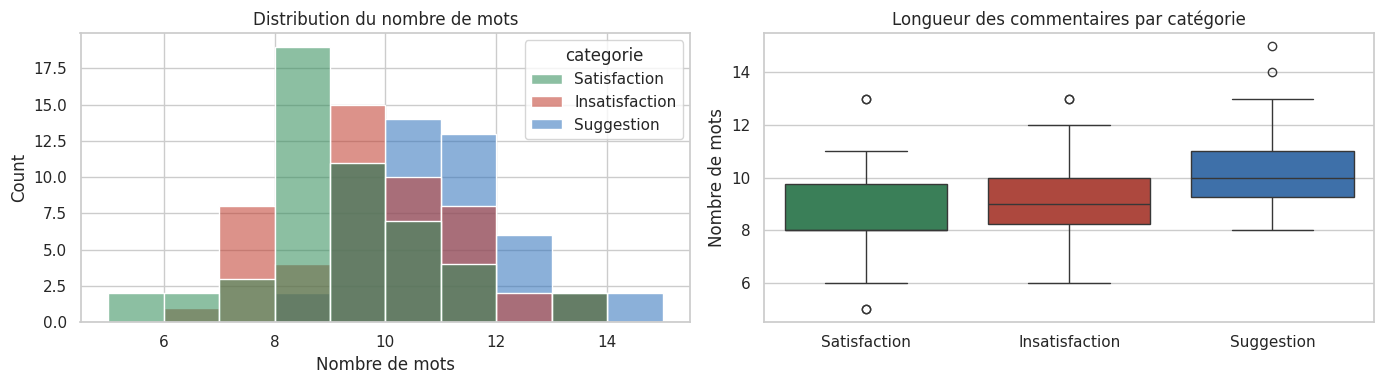

In [7]:
# Distribution des longueurs de texte par catégorie
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="n_mots", hue="categorie", hue_order=CLASSES, palette=PALETTE, multiple="layer",
             binwidth=1, alpha=0.55, ax=axes[0])
axes[0].set_title("Distribution du nombre de mots"); axes[0].set_xlabel("Nombre de mots")
sns.boxplot(data=df, x="categorie", y="n_mots", order=CLASSES, palette=PALETTE, hue="categorie", legend=False, ax=axes[1])
axes[1].set_title("Longueur des commentaires par catégorie"); axes[1].set_xlabel(""); axes[1].set_ylabel("Nombre de mots")
plt.tight_layout(); plt.show()

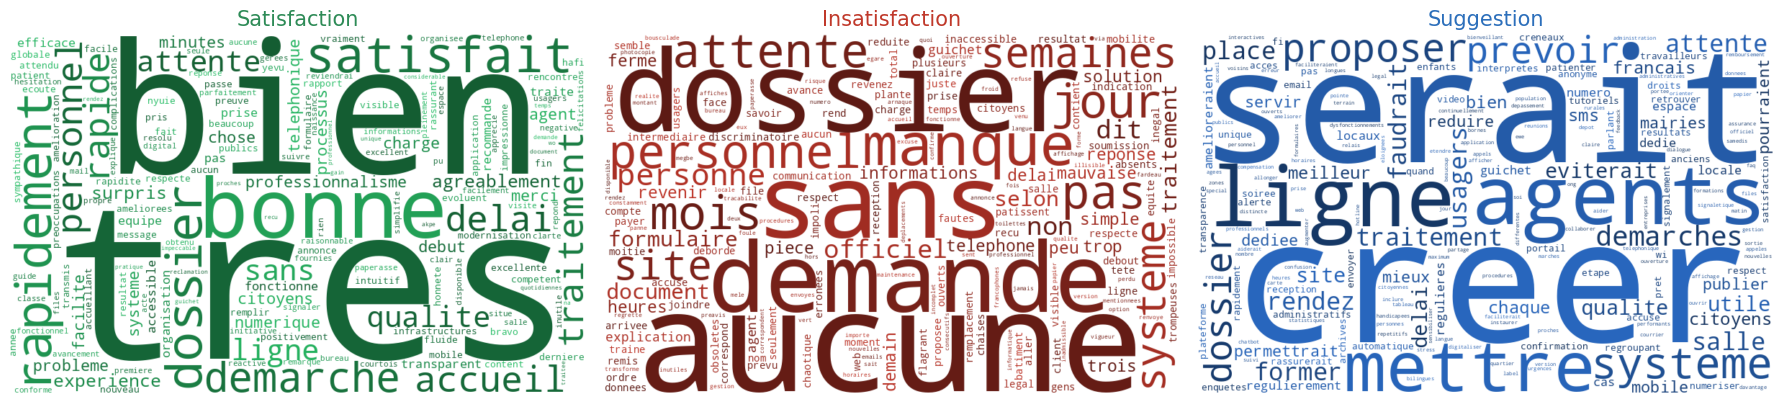

In [8]:
# Nuage de mots par catégorie (texte nettoyé, version "lecture" : mots de contenu uniquement)
hues = {"Satisfaction": 145, "Insatisfaction": 5, "Suggestion": 215}      # teinte de chaque classe

def class_color(hue):
    """Couleurs lisibles (sombres) de la teinte de la classe, tirées avec le random_state du nuage."""
    return lambda *args, random_state=None, **kwargs: f"hsl({hue}, 65%, {random_state.randint(22, 45)}%)"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, category in zip(axes, CLASSES):
    corpus = " ".join(df.loc[df["categorie"] == category, "texte_visu"])
    cloud = WordCloud(width=800, height=500, background_color="white", color_func=class_color(hues[category]),
                      collocations=False, random_state=SEED).generate(corpus)
    ax.imshow(cloud, interpolation="bilinear"); ax.axis("off"); ax.set_title(category, fontsize=15, color=PALETTE[category])
plt.tight_layout(); plt.show()

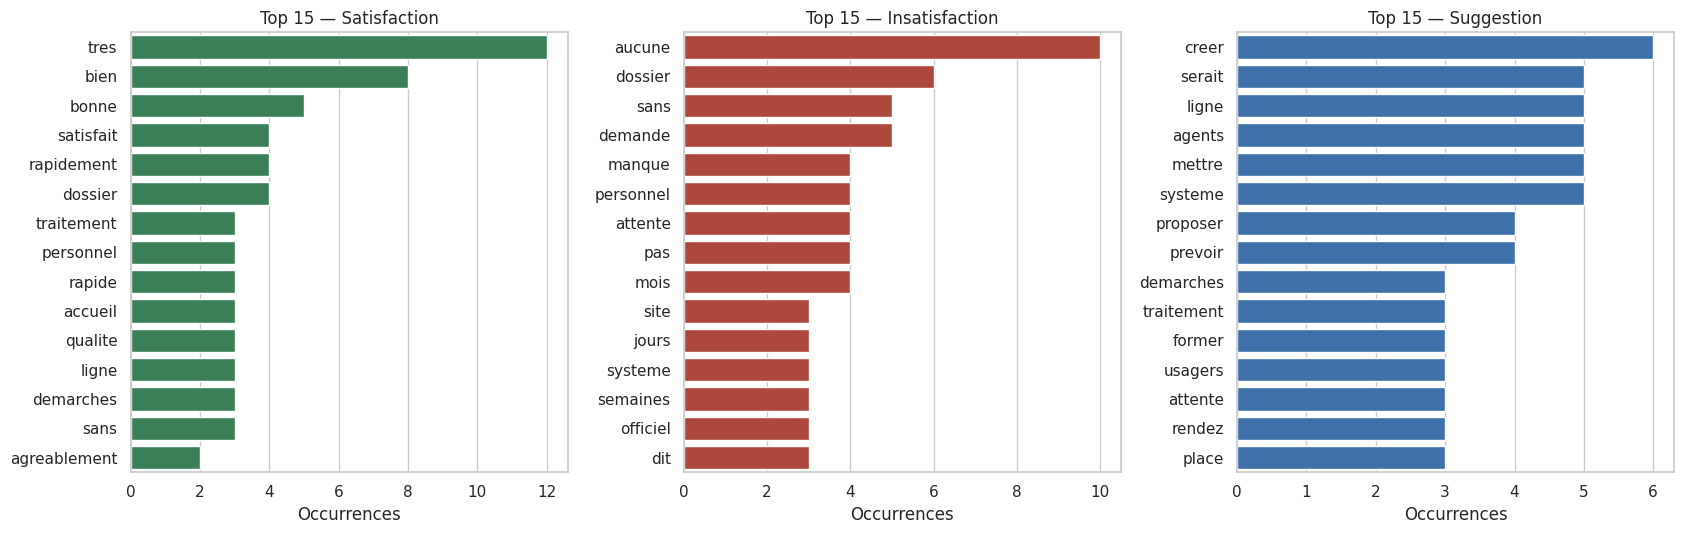

In [9]:
# 15 termes les plus fréquents par catégorie
def top_terms(category, n=15):
    counter = Counter(tok for text in df.loc[df["categorie"] == category, "texte_visu"] for tok in text.split())
    return pd.DataFrame(counter.most_common(n), columns=["terme", "frequence"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, category in zip(axes, CLASSES):
    sns.barplot(data=top_terms(category), y="terme", x="frequence", color=PALETTE[category], ax=ax)
    ax.set_title(f"Top 15 — {category}"); ax.set_xlabel("Occurrences"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Lecture des visualisations.**
- **Satisfaction** : intensifs et adjectifs positifs (*très* — 12 occurrences, *bien*, *bonne*, *satisfait*, *rapidement*, *accueil*, *qualité*).
- **Insatisfaction** : la négation et le manque (*aucune* — 10 occurrences, *sans*, *manque*, *pas*) et le champ lexical de l'attente (*dossier*, *demande*, *attente*, *mois*, *semaines*, *jours*).
- **Suggestion** : verbes d'action à l'infinitif ou au conditionnel (*créer*, *mettre*, *proposer*, *prévoir*, *former*, *serait*) et noms du service (*ligne*, *agents*, *système*).
- Les fréquences sont faibles (maximum 12 occurrences pour 50 commentaires) : le vocabulaire est très varié et, au bas du classement, les ex æquo sont départagés arbitrairement. Les graphiques utilisent la version « lecture » du texte (qui masque aussi *je, ne, pour, service*…) ; le modèle, lui, utilise la version complète.
- **Les mots-outils conservés pour le modèle sont très discriminants** (heatmap ci-dessous) : *« je »* apparaît dans 28 % des Satisfactions et 0 % des Suggestions ; *« très »* dans 24 % des Satisfactions et 0 % des Insatisfactions ; *« aucune »* dans 18 % des Insatisfactions ; *« pour »* dans 38 % des Suggestions ; *« il »* (16 %) et *« serait »* (10 %) presque exclusivement dans les Suggestions. Une liste de stopwords standard aurait effacé ces signaux : c'est la justification chiffrée de la liste maison.

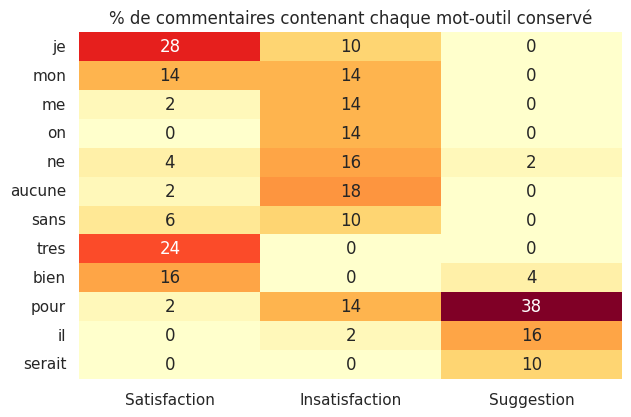

In [10]:
# Preuve chiffrée : les mots-outils CONSERVÉS pour le modèle sont très discriminants (% de commentaires qui les contiennent)
kept_words = ["je", "mon", "me", "on", "ne", "aucune", "sans", "tres", "bien", "pour", "il", "serait"]
presence = pd.DataFrame({word: df["texte_propre"].str.split().apply(lambda tokens: word in tokens) for word in kept_words})
presence_by_class = (presence.groupby(df["categorie"]).mean().loc[CLASSES] * 100).round(0).T
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(presence_by_class, annot=True, fmt=".0f", cmap="YlOrRd", cbar=False, ax=ax)
ax.set_title("% de commentaires contenant chaque mot-outil conservé"); ax.set_xlabel(""); ax.set_ylabel("")
plt.show()

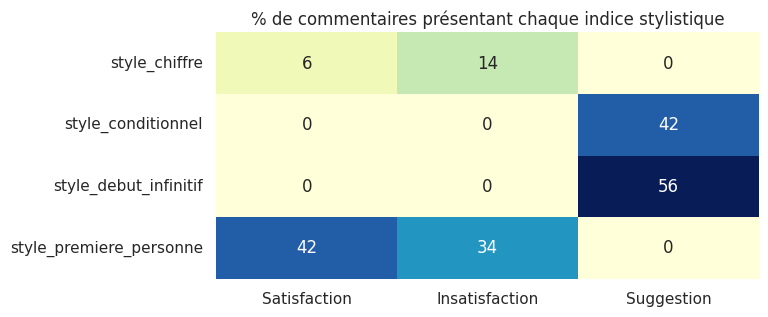

In [11]:
# Indices stylistiques par catégorie (calculés sur le texte brut) : % de commentaires concernés
style_matrix = pd.DataFrame(linguistic_features(df["texte"]), columns=STYLE_FEATURE_NAMES, index=df.index)
style_by_class = (style_matrix.groupby(df["categorie"]).mean().loc[CLASSES] * 100).round(0).T
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.heatmap(style_by_class, annot=True, fmt=".0f", cmap="YlGnBu", cbar=False, ax=ax)
ax.set_title("% de commentaires présentant chaque indice stylistique"); ax.set_xlabel(""); ax.set_ylabel("")
plt.show()

**Constat décisif pour la modélisation.** Deux indices de forme isolent presque entièrement les Suggestions :
- **un conditionnel** (*« serait », « permettrait »…*) : 42 % des Suggestions, **0 %** des deux autres classes ;
- **une formule à l'infinitif de consigne** (*« Créer une… », « Mettre en place… »*) : 56 % des Suggestions, **0 %** des deux autres classes.

À eux deux, ils couvrent **49 Suggestions sur 50**. Autres indices : aucune Suggestion ne contient de pronom de première personne (récit vécu, 34 à 42 % des deux autres classes) ni de chiffre (14 % des Insatisfactions, 6 % des Satisfactions). Ces indices sont calculés sur le **texte brut** — avant que le nettoyage ne supprime chiffres et accents — et ajoutés en parallèle du TF-IDF. Le détecteur d'infinitif exige un déterminant, une préposition ou un adverbe en *-ment* après le verbe, pour ne pas confondre *« Dossier perdu »* ou *« Formulaire illisible »* avec une consigne (faux positif repéré lors de l'analyse d'erreurs d'une première version).

# Partie 2 — Modélisation

## 2.1 Vectorisation et découpage

**Choix : TF-IDF (unigrammes), avec `sublinear_tf=True`.**
- Avec 150 textes courts (≈ 9 mots), des embeddings entraînés sur ce corpus seraient inexploitables, et les embeddings pré-entraînés disponibles ne couvrent pas l'éwé : le bag-of-words pondéré reste la référence robuste en petit corpus.
- TF-IDF atténue les mots omniprésents (« service », « dossier ») et valorise les termes discriminants ; il reste **interprétable** (on peut lire les coefficients du modèle, cf. 2.3).
- Le choix est **vérifié empiriquement** ci-dessous contre `CountVectorizer`, des bigrammes et des n-grammes de caractères (robustes aux variantes orthographiques éwé).

**Découpage** : 80 % entraînement / 20 % test, **stratifié** (les classes restent équilibrées), `random_state=42`. Le texte brut est découpé *avant* tout traitement et le nettoyage est **intégré aux pipelines** : aucune information du jeu de test ne fuit vers l'entraînement.

In [12]:
X, y = df["texte"], df["categorie"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Entraînement : {len(X_train)} | Test : {len(X_test)}")
display(pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).loc[CLASSES])

Entraînement : 120 | Test : 30


,train,test
categorie,,
Satisfaction,40,10
Insatisfaction,40,10
Suggestion,40,10


In [13]:
# --- Construction des pipelines : nettoyage -> vectorisation (+ indices stylistiques) -> classifieur ---
def build_pipeline(classifier, use_style_features=False, vectorizer=None, **clean_kwargs):
    """Pipeline de bout en bout : prend du texte BRUT en entrée (sans fuite de données lors des validations croisées)."""
    text_branch = Pipeline([
        ("nettoyage", FunctionTransformer(clean_batch, kw_args=clean_kwargs)),
        ("vectorisation", vectorizer if vectorizer is not None else TfidfVectorizer(sublinear_tf=True)),
    ])
    branches = [("texte", text_branch)]
    if use_style_features:
        branches.append(("style", FunctionTransformer(linguistic_features)))
    return Pipeline([("features", FeatureUnion(branches)), ("classifieur", classifier)])


def get_classifiers():
    """4 algorithmes de familles différentes (linéaire, marge, probabiliste, ensemble d'arbres)."""
    return {
        "Régression logistique": LogisticRegression(C=10, max_iter=2000, random_state=SEED),
        "SVM linéaire": LinearSVC(C=1.0, random_state=SEED),
        "Naive Bayes": MultinomialNB(alpha=0.3),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    }

# Validation croisée répétée (5 plis x 5 répétitions) : le jeu de test ne compte que 30 exemples,
# une seule mesure serait très bruitée (1 erreur = 3,3 points d'accuracy).
CV_REPEATED = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

def cv_f1(pipeline):
    scores = cross_validate(pipeline, X, y, cv=CV_REPEATED, scoring="f1_macro", n_jobs=-1)["test_score"]
    return scores.mean(), scores.std()

In [14]:
# Comparaison empirique des méthodes de vectorisation (régression logistique, validation croisée 5x5).
# Les "indices stylistiques" sont présentés en 2.2 ; ils sont inclus ici pour juger chaque vectorisation dans la configuration finale.
vectorizers = {
    "TF-IDF mots (1-gramme)": TfidfVectorizer(sublinear_tf=True),
    "TF-IDF mots (1-2 grammes)": TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2)),
    "CountVectorizer (1-gramme)": CountVectorizer(),
    "TF-IDF caractères (2-4 grammes)": TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), sublinear_tf=True),
}
rows = []
for label, vec in vectorizers.items():
    classifier = LogisticRegression(C=10, max_iter=2000, random_state=SEED)
    text_only, text_only_std = cv_f1(build_pipeline(classifier, vectorizer=clone(vec)))
    with_style, with_style_std = cv_f1(build_pipeline(classifier, use_style_features=True, vectorizer=clone(vec)))
    rows.append({"Vectorisation": label, "F1 macro CV — texte seul": round(text_only, 3), "± ": round(text_only_std, 3),
                 "F1 macro CV — + indices stylistiques": round(with_style, 3), "±": round(with_style_std, 3)})
display(pd.DataFrame(rows).set_index("Vectorisation"))

,F1 macro CV — texte seul,±,F1 macro CV — + indices stylistiques,±
Vectorisation,,,,
TF-IDF mots (1-gramme),0.706,0.098,0.863,0.064
TF-IDF mots (1-2 grammes),0.688,0.087,0.839,0.077
CountVectorizer (1-gramme),0.708,0.074,0.856,0.059
TF-IDF caractères (2-4 grammes),0.728,0.091,0.831,0.078


**Lecture.** Avec le texte seul, les écarts sont dans le bruit statistique (écart-type ≈ 0,09) : les n-grammes de caractères sont légèrement devant (0,728) et les bigrammes de mots derrière (0,688). Une fois les indices stylistiques ajoutés — configuration finale — **TF-IDF sur les mots isolés est le meilleur (0,863)**, devant `CountVectorizer` (0,856, ex æquo statistique), les bigrammes (0,839) et les caractères (0,831) : sur 120 exemples d'entraînement, les n-grammes supplémentaires ajoutent surtout du bruit. **TF-IDF unigrammes est donc retenu**, à égalité de performance avec le simple comptage mais avec une pondération qui atténue les mots omniprésents.

## 2.2 Entraînement et 2.3 Évaluation

Quatre algorithmes sont entraînés dans **deux variantes** : *(a)* TF-IDF seul, *(b)* TF-IDF + 4 indices stylistiques binaires (chiffre, conditionnel, début à l'infinitif, pronom de 1ʳᵉ personne), motivés par l'analyse exploratoire (heatmap de 1.3).

In [15]:
def evaluate_models(models):
    """Entraîne chaque pipeline sur le train, évalue sur le test (Accuracy, F1 macro) + F1 macro en validation croisée."""
    rows, predictions = [], {}
    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        predictions[name] = y_pred
        cv_mean, cv_std = cv_f1(clone(pipeline))
        rows.append({"Modèle": name,
                     "Accuracy (test)": accuracy_score(y_test, y_pred),
                     "F1 macro (test)": f1_score(y_test, y_pred, average="macro"),
                     "F1 macro (CV 5x5)": cv_mean, "± CV": cv_std})
    return pd.DataFrame(rows).set_index("Modèle").round(3), predictions


def plot_confusion_matrices(predictions, title):
    fig, axes = plt.subplots(1, len(predictions), figsize=(4.6 * len(predictions), 4.2))
    for ax, (name, y_pred) in zip(np.atleast_1d(axes), predictions.items()):
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=CLASSES, cmap="Blues", colorbar=False, ax=ax,
                                                xticks_rotation=30)
        ax.set_title(name)
    fig.suptitle(title, y=1.02, fontsize=14); plt.tight_layout(); plt.show()

,Accuracy (test),F1 macro (test),F1 macro (CV 5x5),± CV
Modèle,,,,
Régression logistique,0.767,0.768,0.706,0.098
SVM linéaire,0.833,0.833,0.704,0.095
Naive Bayes,0.767,0.768,0.701,0.098
Random Forest,0.800,0.801,0.678,0.067


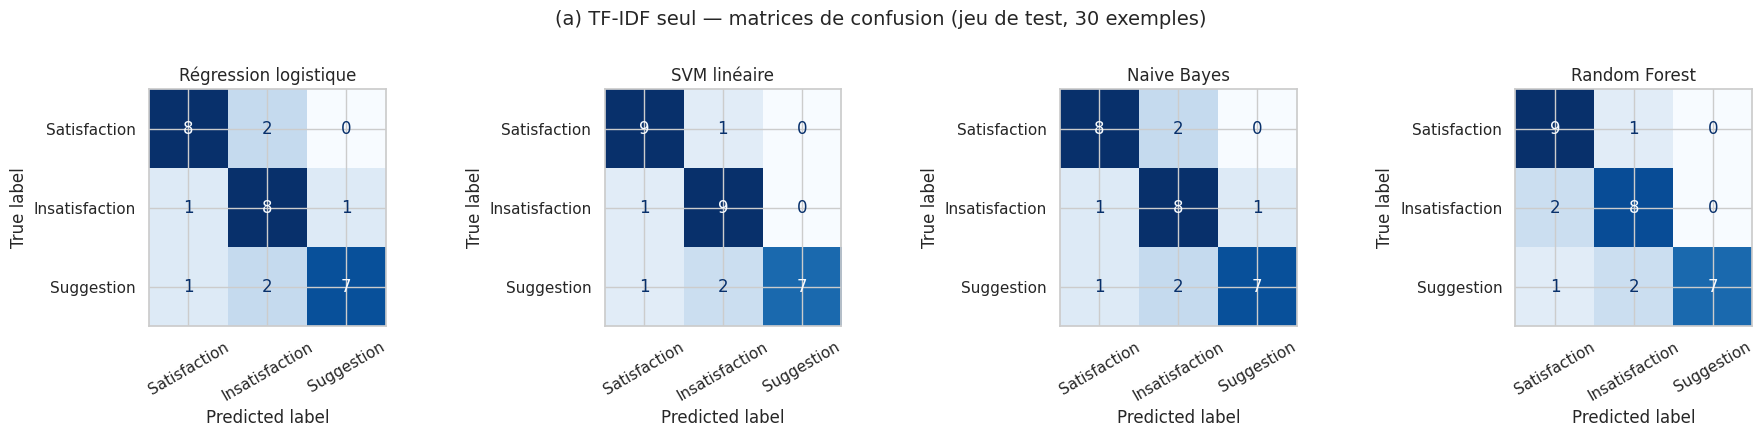

In [16]:
# (a) Référence : TF-IDF seul
baseline_models = {name: build_pipeline(clf) for name, clf in get_classifiers().items()}
baseline_table, baseline_preds = evaluate_models(baseline_models)
display(baseline_table)
plot_confusion_matrices(baseline_preds, "(a) TF-IDF seul — matrices de confusion (jeu de test, 30 exemples)")

,Accuracy (test),F1 macro (test),F1 macro (CV 5x5),± CV
Modèle,,,,
Régression logistique,0.967,0.967,0.863,0.064
SVM linéaire,0.933,0.933,0.863,0.065
Naive Bayes,0.900,0.898,0.789,0.079
Random Forest,0.900,0.900,0.846,0.072


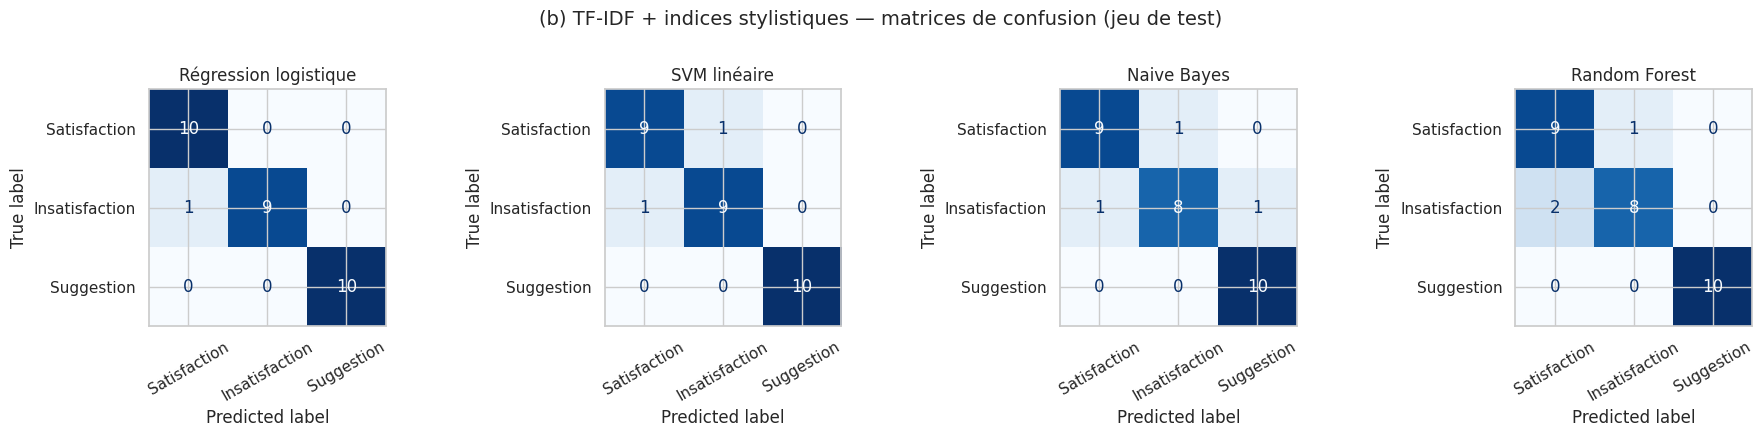

In [17]:
# (b) TF-IDF + indices stylistiques
style_models = {name: build_pipeline(clf, use_style_features=True) for name, clf in get_classifiers().items()}
style_table, style_preds = evaluate_models(style_models)
display(style_table)
plot_confusion_matrices(style_preds, "(b) TF-IDF + indices stylistiques — matrices de confusion (jeu de test)")

**Lecture des résultats.**
- **TF-IDF seul** : les quatre algorithmes sont indiscernables (F1 macro en validation croisée entre 0,68 et 0,71, écart-type ≈ 0,1). Le choix de l'algorithme compte peu ; c'est la représentation qui limite la performance.
- **Avec les indices stylistiques**, le gain est net et constant : **+0,16 de F1 macro (CV) pour la régression logistique et le SVM** (0,706 → 0,863), +0,17 pour la Random Forest, +0,09 pour Naive Bayes. Régression logistique et SVM linéaire arrivent à égalité (0,863) ; Naive Bayes est en retrait (0,789), probablement parce que son hypothèse d'indépendance s'accommode mal d'indices binaires corrélés.
- **Précaution sur le jeu de test** : avec 30 exemples, une erreur coûte 3,3 points d'accuracy. 0,967 contre 0,933 ne constitue donc pas une différence significative : **la validation croisée répétée (150 exemples, 25 évaluations) est la mesure fiable**, le test donne une confirmation indépendante.
- **Matrices de confusion** : la classe Suggestion est quasiment jamais confondue ; les erreurs restantes se concentrent sur le couple **Satisfaction ↔ Insatisfaction** (analysé plus bas).

### Optimisation des hyperparamètres (sur le jeu d'entraînement uniquement)

Je retiens la régression logistique avec indices stylistiques (meilleur compromis performance / stabilité / interprétabilité, et elle fournit des probabilités pour l'interface). La grille est explorée par validation croisée **sur le train seul** ; le test n'est utilisé qu'une fois, à la fin.

Meilleurs hyperparamètres : {'classifieur__C': 3, 'features__texte__vectorisation__min_df': 1, 'features__texte__vectorisation__ngram_range': (1, 1)}
F1 macro (CV sur le train) : 0.841

TEST — Accuracy : 0.967 | F1 macro : 0.967
                precision    recall  f1-score   support

  Satisfaction      0.909     1.000     0.952        10
Insatisfaction      1.000     0.900     0.947        10
    Suggestion      1.000     1.000     1.000        10

      accuracy                          0.967        30
     macro avg      0.970     0.967     0.967        30
  weighted avg      0.970     0.967     0.967        30



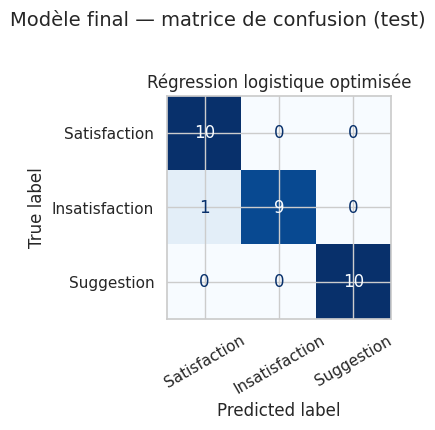

In [18]:
param_grid = {
    "features__texte__vectorisation__ngram_range": [(1, 1), (1, 2)],
    "features__texte__vectorisation__min_df": [1, 2],
    "classifieur__C": [0.3, 1, 3, 10, 30],
}
grid = GridSearchCV(build_pipeline(LogisticRegression(max_iter=2000, random_state=SEED), use_style_features=True),
                    param_grid, scoring="f1_macro", cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)
grid.fit(X_train, y_train)
print("Meilleurs hyperparamètres :", grid.best_params_)
print(f"F1 macro (CV sur le train) : {grid.best_score_:.3f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"\nTEST — Accuracy : {accuracy_score(y_test, y_pred_best):.3f} | F1 macro : {f1_score(y_test, y_pred_best, average='macro'):.3f}")
print(classification_report(y_test, y_pred_best, labels=CLASSES, digits=3))
plot_confusion_matrices({"Régression logistique optimisée": y_pred_best}, "Modèle final — matrice de confusion (test)")

In [19]:
# Tableau de synthèse final
cv_mean, cv_std = cv_f1(clone(best_model))
tuned_row = pd.DataFrame([{"Accuracy (test)": accuracy_score(y_test, y_pred_best),
                           "F1 macro (test)": f1_score(y_test, y_pred_best, average="macro"),
                           "F1 macro (CV 5x5)": cv_mean, "± CV": cv_std}], index=["Régression logistique optimisée"]).round(3)
summary = pd.concat([baseline_table.assign(Variante="TF-IDF seul"),
                     style_table.assign(Variante="TF-IDF + style"),
                     tuned_row.assign(Variante="TF-IDF + style (optimisé)")])
summary = summary.reset_index().rename(columns={"index": "Modèle"}).set_index(["Variante", "Modèle"])
display(summary.sort_values("F1 macro (CV 5x5)", ascending=False))

Accuracy (test)  \
Variante                  Modèle                                             
TF-IDF + style            Régression logistique                      0.967   
                          SVM linéaire                               0.933   
TF-IDF + style (optimisé) Régression logistique optimisée            0.967   
TF-IDF + style            Random Forest                              0.900   
                          Naive Bayes                                0.900   
TF-IDF seul               Régression logistique                      0.767   
                          SVM linéaire                               0.833   
                          Naive Bayes                                0.767   
                          Random Forest                              0.800   

                                                           F1 macro (test)  \
Variante                  Modèle                                             
TF-IDF + style            Régression logistique                      0.967   
                          SVM linéaire                               0.933   
TF-IDF + style (optimisé) Régression logistique optimisée            0.967   
TF-IDF + style            Random Forest                              0.900   
                          Naive Bayes                                0.898   
TF-IDF seul               Régression logistique                      0.768   
                          SVM linéaire                               0.833   
                          Naive Bayes                                0.768   
                          Random Forest                              0.801   

                                                           F1 macro (CV 5x5)  \
Variante                  Modèle                                               
TF-IDF + style            Régression logistique                        0.863   
                          SVM linéaire                                 0.863   
TF-IDF + style (optimisé) Régression logistique optimisée              0.861   
TF-IDF + style            Random Forest                                0.846   
                          Naive Bayes                                  0.789   
TF-IDF seul               Régression logistique                        0.706   
                          SVM linéaire                                 0.704   
                          Naive Bayes                                  0.701   
                          Random Forest                                0.678   

                                                            ± CV  
Variante                  Modèle                                  
TF-IDF + style            Régression logistique            0.064  
                          SVM linéaire                     0.065  
TF-IDF + style (optimisé) Régression logistique optimisée  0.064  
TF-IDF + style            Random Forest                    0.072  
                          Naive Bayes                      0.079  
TF-IDF seul               Régression logistique            0.098  
                          SVM linéaire                     0.095  
                          Naive Bayes                      0.098  
                          Random Forest                    0.067

**Modèle retenu : régression logistique + TF-IDF (unigrammes) + 4 indices stylistiques.**
- La grille retient `C = 3`, unigrammes, `min_df = 1` ; le score en validation croisée sur le train (0,841) est cohérent avec la CV globale (0,861).
- **Test : 29 / 30 (accuracy = F1 macro = 0,967).** Satisfaction : rappel 1,00 ; Insatisfaction : précision 1,00, rappel 0,90 ; Suggestion : 1,00 partout.
- L'optimisation **n'apporte pas de gain** par rapport aux valeurs initiales (`C = 10` : 0,863 en CV vs 0,861) : la performance est sur un plateau stable, ce qui est plutôt rassurant.
- **Estimation honnête de la performance** : le 0,967 du test est favorable (30 exemples, 1 seule erreur). La valeur à retenir est le **F1 macro d'environ 0,86 ± 0,06 en validation croisée répétée**.

### Impact des choix de prétraitement (validation croisée, modèle final)

Les décisions de nettoyage (stopwords maison, stratégie éwé) sont testées sur le modèle optimisé : le notebook ne se contente pas de les *justifier*, il les *mesure*.

In [20]:
ablations = {
    "Référence : stopwords maison, éwé conservé": {},
    "Sans suppression des stopwords": {"remove_stopwords": False},
    "Éwé traduit (glossaire sûr)": {"ewe_strategy": "translate"},
    "Éwé supprimé": {"ewe_strategy": "remove"},
}
rows = []
for label, kwargs in ablations.items():
    pipeline = clone(best_model).set_params(features__texte__nettoyage__kw_args=kwargs)
    mean, std = cv_f1(pipeline)
    rows.append({"Variante de prétraitement": label, "F1 macro (CV 5x5)": round(mean, 3), "± écart-type": round(std, 3)})
display(pd.DataFrame(rows).set_index("Variante de prétraitement"))

,F1 macro (CV 5x5),± écart-type
Variante de prétraitement,,
"Référence : stopwords maison, éwé conservé",0.861,0.064
Sans suppression des stopwords,0.837,0.070
Éwé traduit (glossaire sûr),0.861,0.064
Éwé supprimé,0.859,0.065


**Lecture.**
- **Stopwords** : la liste maison apporte **+0,024 de F1 macro** (0,861 contre 0,837 sans filtrage) : retirer le bruit grammatical aide, à condition de conserver négations, pronoms et marqueurs de modalité.
- **Stratégie éwé/mina** : conserver (0,861), traduire (0,861) ou supprimer (0,859) donne le même résultat à ±0,002 près, soit bien moins que l'écart-type. Avec 3 commentaires sur 150, l'effet est **mesurable en théorie, indétectable en pratique** : je ne prétends donc pas qu'une stratégie soit meilleure. Je retiens `keep` (aucune perte d'information, aucune traduction hasardeuse), avec le glossaire prêt à être étendu si la proportion de commentaires éwé/mina augmente.

## Analyse des erreurs

Le jeu de test ne contient que 30 exemples : il produit trop peu d'erreurs pour en tirer des enseignements. J'analyse donc **les prédictions "out-of-fold"** (validation croisée 5 plis sur les 150 commentaires : chaque commentaire est prédit par un modèle qui ne l'a jamais vu), en commençant par les erreurs du test.

In [21]:
classes_model = list(best_model.classes_)
oof_proba = cross_val_predict(clone(best_model), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method="predict_proba")
oof = pd.DataFrame(oof_proba, columns=classes_model, index=df.index)
oof["prediction"] = oof[classes_model].idxmax(axis=1)
oof["confiance"] = oof[classes_model].max(axis=1)

errors = df[["texte", "categorie"]].join(oof[["prediction", "confiance"]]).query("categorie != prediction")
print(f"Erreurs sur le jeu de test : {int((y_test != y_pred_best).sum())} / {len(y_test)}")
print(f"Erreurs out-of-fold : {len(errors)} / {len(df)}  (accuracy OOF = {1 - len(errors) / len(df):.3f})\n")

display(pd.crosstab(df["categorie"], oof["prediction"]).loc[CLASSES, CLASSES].rename_axis(index="Vrai", columns="Prédit"))
print("Les 5 erreurs commises avec le plus de confiance :")
worst = errors.sort_values("confiance", ascending=False).head(5)
display(worst.assign(texte_propre=df.loc[worst.index, "texte_propre"]))

Erreurs sur le jeu de test : 1 / 30
Erreurs out-of-fold : 24 / 150  (accuracy OOF = 0.840)



Prédit,Satisfaction,Insatisfaction,Suggestion
Vrai,,,
Satisfaction,39,11,0
Insatisfaction,12,38,0
Suggestion,1,0,49


Les 5 erreurs commises avec le plus de confiance :


,texte,categorie,prediction,confiance,texte_propre
74,"Service de première classe, je n'ai aucune remarque négative.",Satisfaction,Insatisfaction,0.777820,service premiere classe je ne aucune remarque negative
46,Je n'ai attendu que 10 minutes avant d'être pris en charge.,Satisfaction,Insatisfaction,0.777576,je ne attendu minutes pris en charge
49,Je n'ai reçu aucun accusé de réception de ma demande.,Insatisfaction,Satisfaction,0.731038,je ne recu aucun accuse reception ma demande
97,Dossier traité rapidement et sans paperasse inutile.,Satisfaction,Insatisfaction,0.685899,dossier traite rapidement sans paperasse inutile
77,La clarté des informations fournies facilite les démarches.,Satisfaction,Insatisfaction,0.681527,clarte informations fournies facilite demarches


**Analyse des 5 erreurs les plus « confiantes »** (la contribution de chaque variable à la décision a été vérifiée en réentraînant le modèle sans le commentaire concerné) :

| # | Commentaire | Vrai → prédit | Explication |
|---|---|---|---|
| 74 | *« Service de première classe, je n'ai aucune remarque négative. »* | Satisfaction → Insatisfaction | **Négation à portée limitée** : *aucune* et *ne* poussent fortement vers l'Insatisfaction ; le sac de mots ne voit pas que *« aucune remarque négative »* est un compliment. |
| 46 | *« Je n'ai attendu que 10 minutes avant d'être pris en charge. »* | Satisfaction → Insatisfaction | **Restriction *ne… que*** = durée courte (positif), mais le modèle voit *ne* et surtout l'indice « chiffre », plus fréquent dans les plaintes chiffrées (14 % contre 6 %) : fausse piste statistique. |
| 49 | *« Je n'ai reçu aucun accusé de réception de ma demande. »* (seule erreur du test) | Insatisfaction → Satisfaction | Le gabarit *« Je… reçu… ma demande »* ressemble à des Satisfactions (*« J'ai reçu mon document dans les délais »*). Les négations (*aucun*) figurent aussi dans des commentaires positifs (*« Aucun problème rencontré »*) : elles sont ambiguës. |
| 97 | *« Dossier traité rapidement et sans paperasse inutile. »* | Satisfaction → Insatisfaction | Vocabulaire de plainte (*sans*, *paperasse*, *dossier*) alors que *« sans… inutile »* exprime l'absence d'un défaut ; *rapidement* et *traité* ne suffisent pas à compenser. |
| 77 | *« La clarté des informations fournies facilite les démarches. »* | Satisfaction → Insatisfaction (confiance 0,68) | Phrase **descriptive sans marqueur d'opinion** (ni pronom ni intensif). Erreur peu confiante et instable : elle disparaît quand on entraîne sur 149 exemples au lieu de 120 — frontière de décision fragile faute de données. |

**Bilan.** Sur les 24 erreurs « out-of-fold », **23 concernent la polarité Satisfaction ↔ Insatisfaction** (11 + 12) ; une seule touche les Suggestions : *« Un espace dédié aux jeunes et étudiants avec accompagnement personnalisé »*, la seule Suggestion sans conditionnel ni infinitif. Le goulot d'étranglement est donc la **composition de la négation et de la polarité**, qu'un sac de mots ne sait pas modéliser.

In [22]:
# Interprétabilité : termes les plus influents par classe (coefficients de la régression logistique)
vectorizer = best_model.named_steps["features"].transformer_list[0][1].named_steps["vectorisation"]
feature_names = np.r_[vectorizer.get_feature_names_out(), STYLE_FEATURE_NAMES]
coefficients = pd.DataFrame(best_model.named_steps["classifieur"].coef_, index=best_model.classes_, columns=feature_names)
top_features = {cls: ", ".join(coefficients.loc[cls].nlargest(8).index) for cls in CLASSES}
display(pd.Series(top_features, name="8 variables les plus favorables à la classe").to_frame())

,8 variables les plus favorables à la classe
Satisfaction,"tres, bien, je, rapidement, style_premiere_personne, bonne, service, demarches"
Insatisfaction,"aucune, on, mois, ne, me, manque, telephone, jours"
Suggestion,"style_debut_infinitif, style_conditionnel, accompagnement, dedie, etudiants, jeunes, personnalise, espace"


**Lecture.** Les coefficients confirment l'analyse exploratoire : Suggestion portée par l'infinitif et le conditionnel ; Satisfaction par *très, bien, bonne, rapidement* et la première personne ; Insatisfaction par *aucune, ne, manque* et des termes d'attente (*mois, jours*). Les termes de contenu de la Suggestion (*accompagnement, dédié, étudiants, jeunes…*) proviennent d'un ou deux exemples et relèvent du **sur-apprentissage** : c'est un signal d'alerte sur la taille du corpus plutôt qu'une règle générale.

# Partie 3 — Restitution et bonus

## Bonus : modèle sauvegardé et gestion des commentaires mixtes français/éwé

Le modèle final est réentraîné sur les **150 commentaires** (les hyperparamètres ont déjà été fixés sans regarder le test) puis sauvegardé. Il prend du **texte brut** en entrée : le nettoyage et les indices stylistiques sont inclus dans le pipeline. Il alimente l'interface Streamlit `app.py`.

In [23]:
final_model = clone(best_model).fit(X, y)
joblib.dump(final_model, "model.joblib")

reloaded = joblib.load("model.joblib")
new_comments = [
    "Akpe na wò, le service était rapide et efficace.",                      # mixte, satisfaction
    "Mele via o, mon dossier est perdu depuis trois semaines.",              # mixte, insatisfaction
    "Il faudrait ouvrir un guichet spécial le samedi matin.",                # suggestion
    "Aucune réponse à mes appels, c'est inadmissible.",                      # insatisfaction
    "Tout s'est bien passé, merci à toute l'équipe.",                        # satisfaction
]
probabilities = pd.DataFrame(reloaded.predict_proba(pd.Series(new_comments)), columns=reloaded.classes_).round(2)
demo = pd.DataFrame({"commentaire": new_comments, "prédiction": reloaded.predict(pd.Series(new_comments)),
                     "éwé détecté": [contains_ewe(c) for c in new_comments]}).join(probabilities)
display(demo)

,commentaire,prédiction,éwé détecté,Insatisfaction,Satisfaction,Suggestion
0,"Akpe na wò, le service était rapide et efficace.",Satisfaction,True,0.17,0.79,0.04
1,"Mele via o, mon dossier est perdu depuis trois semaines.",Insatisfaction,True,0.78,0.21,0.01
2,Il faudrait ouvrir un guichet spécial le samedi matin.,Suggestion,False,0.03,0.02,0.95
3,"Aucune réponse à mes appels, c'est inadmissible.",Insatisfaction,False,0.61,0.37,0.01
4,"Tout s'est bien passé, merci à toute l'équipe.",Satisfaction,False,0.14,0.83,0.04


**Interface de test (bonus).** Lancer `streamlit run app.py` : saisie d'un commentaire (ou d'un exemple prêt à l'emploi), prédiction, probabilités par classe, texte nettoyé et détection des termes éwé/mina.

**Commentaires mixtes.** Le traitement spécifique est intégré au pipeline : lettres éwé préservées par le nettoyage, détection automatique (`contains_ewe`), glossaire de traduction sûre, et choix de la stratégie mesuré en validation croisée (cf. section « Impact des choix de prétraitement »).

# Conclusion

## Résultats
Le meilleur pipeline — **régression logistique sur TF-IDF + 4 indices stylistiques, avec nettoyage maison** — atteint **29/30 sur le jeu de test (accuracy = F1 macro = 0,967)** et un **F1 macro de ≈ 0,86 ± 0,06 en validation croisée répétée**, contre 0,70 pour un TF-IDF classique. Trois décisions expliquent l'essentiel du résultat, chacune **mesurée** dans ce notebook : les indices stylistiques (+0,09 à +0,17), la liste de stopwords adaptée (+0,024) et le choix de la représentation plutôt que de l'algorithme (4 algorithmes équivalents en TF-IDF seul).

## Limites
1. **Très petit corpus** (150 textes, 30 en test) : une erreur vaut 3,3 points, les écarts de moins de 0,05 ne sont pas significatifs, et quelques termes de contenu sont sur-appris (cf. coefficients).
2. **Corpus très formaté** : le conditionnel et l'infinitif de consigne isolent 49 Suggestions sur 50. Ces indices exploitent des conventions d'écriture de ce jeu de données ; sur de vrais commentaires (bruités, SMS, fautes, registres mixtes), leur apport serait moindre et la performance plus faible.
3. **Sac de mots et négation** : 23 des 24 erreurs « out-of-fold » portent sur Satisfaction ↔ Insatisfaction (*« aucune remarque négative »*, *« n'ai attendu que 10 minutes »*, *« sans paperasse inutile »*).
4. **Éwé/mina** : 3 commentaires seulement (2 %) ; la stratégie ne peut pas être validée statistiquement. Le glossaire ne contient que 2 traductions certaines (*akpe*, *nyuie*) ; les autres termes (*mele, via, megbe, yevu, hafi*) restent opaques pour le modèle.
5. **Évaluation** : les choix de représentation ont été comparés par validation croisée sur l'ensemble des 150 exemples (léger optimisme possible), sans jeu de validation externe.
6. **Fine-tuning de transformers non réalisé** (bonus) : voir la première piste d'amélioration.

## Pistes d'amélioration
1. **Modèles pré-entraînés multilingues** : fine-tuner CamemBERT ou XLM-R (idéalement un modèle couvrant les langues africaines, de type AfroXLMR), ou, à moindre coût, entraîner une régression logistique sur des embeddings de phrases multilingues (LaBSE). Ils captent la composition de la négation et une partie du code-switching.
2. **Négation explicite** : marquer la portée de la négation (préfixer par `NEG_` les tokens suivant *ne, aucun, sans, jamais* jusqu'à la ponctuation), ou ajouter un lexique de polarité du français ; viser spécifiquement les 23 erreurs de polarité.
3. **Plus de données et un éwé/mina mieux traité** : collecter et annoter de vrais commentaires (double relecture), augmenter par paraphrase et par code-switching, faire valider un glossaire éwé/mina par des locuteurs natifs, et ajouter une détection de langue au niveau du mot.
4. **Évaluation plus robuste** : intervalles de confiance par bootstrap, validation imbriquée pour l'optimisation, et jeu de test collecté séparément pour mesurer la généralisation hors gabarit.

**Reproductibilité** : graine unique (`SEED = 42`), `requirements.txt`, et même module `nlp_utils.py` pour le notebook et l'interface `app.py`.